In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
data = pd.read_csv("housing_price_dataset.csv")

print("Dataset Preview")
print(data.head())

Dataset Preview
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0   5231333  1660         1          2        3      yes       yes      yes   
1  13984976  4572         3          2        3      yes        no       no   
2  12129175  3892         4          3        3       no        no       no   
3   3780668  1266         2          1        1      yes        no       no   
4  12900204  4244         4          2        1      yes        no       no   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0             yes             yes        2      yes        furnished  
1             yes              no        3      yes        furnished  
2              no              no        1       no      unfurnished  
3             yes             yes        1       no   semi-furnished  
4              no             yes        3       no   semi-furnished  


In [3]:

X = data[['area', 'bedrooms', 'bathrooms']]
y = data['price']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [4]:
predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("\nModel Evaluation")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)


Model Evaluation
MAE: 94400.78937449353
RMSE: 110529.77995399767
R2 Score: 0.9990557003659756


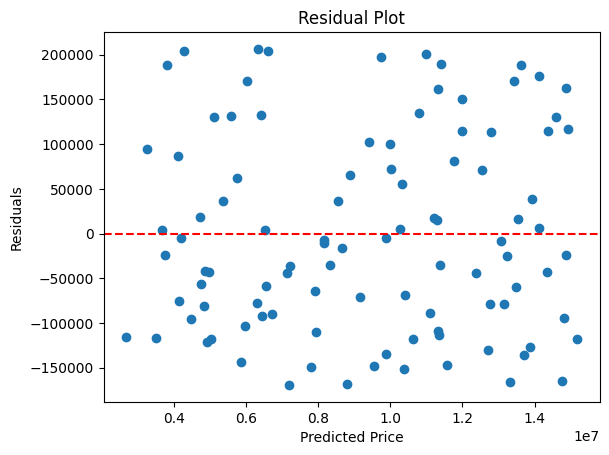

In [5]:
residuals = y_test - predictions

plt.scatter(predictions, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


In [6]:

area =int(input("Enter house area:  "))
bedrooms=int(input("Enter no of bedrooms: "))
bathrooms=int(input("Enter no of bathrooms:"))
new_house = [[area, bedrooms, bathrooms]]
predicted_price = model.predict(new_house)

print("\nPredicted Price for 2100 sqft house:", predicted_price[0])


Predicted Price for 2100 sqft house: 6633679.09465306


c:\Users\sushank varshith\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
